# Credit Card Fraud Detection

## Objective
Identify **fraudulent credit card transactions** using machine learning.

## Dataset Overview
The dataset contains anonymized credit card transactions labeled as fraud or not.

- `Time`, `Amount`, and anonymized features `V1` to `V28`
- `Class`: 1 for fraud, 0 for non-fraud

## Workflow
1. Load and explore the dataset
2. Handle class imbalance
3. Feature scaling and model training
4. Evaluate performance

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              average_precision_score, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42


In [2]:
# Load the dataset
df = pd.read_csv("creditcard.csv")
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Basic sanity checks
print("Shape:", df.shape)
print("\nMissing values per column:\n", df.isnull().sum().sum(), "total missing values")
print("\nDuplicate rows:", df.duplicated().sum())


Shape: (284807, 31)

Missing values per column:
 0 total missing values

Duplicate rows: 1081


## Exploratory Data Analysis

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


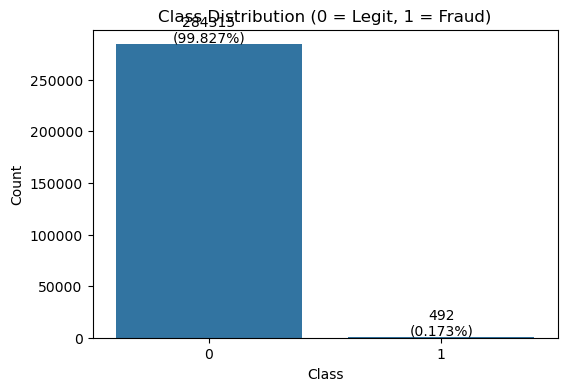

In [4]:
# Count of fraud vs non-fraud
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100
print(class_counts)
print(class_pct)

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Legit, 1 = Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")
for i, v in enumerate(class_counts):
    plt.text(i, v + 2000, f"{v}\n({class_pct[i]:.3f}%)", ha='center')
plt.show()


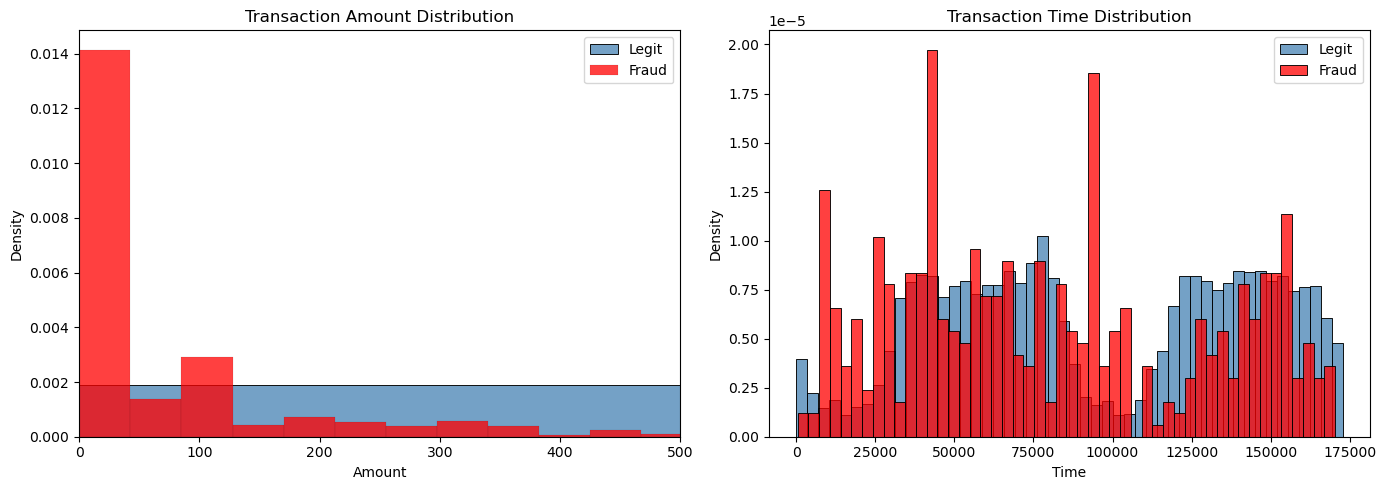

In [5]:
# Distribution of Amount and Time for fraud vs non-fraud
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[df['Class']==0]['Amount'], bins=50, color='steelblue', label='Legit', stat='density', ax=axes[0])
sns.histplot(df[df['Class']==1]['Amount'], bins=50, color='red', label='Fraud', stat='density', ax=axes[0])
axes[0].set_xlim(0, 500)
axes[0].set_title("Transaction Amount Distribution")
axes[0].legend()

sns.histplot(df[df['Class']==0]['Time'], bins=50, color='steelblue', label='Legit', stat='density', ax=axes[1])
sns.histplot(df[df['Class']==1]['Time'], bins=50, color='red', label='Fraud', stat='density', ax=axes[1])
axes[1].set_title("Transaction Time Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()


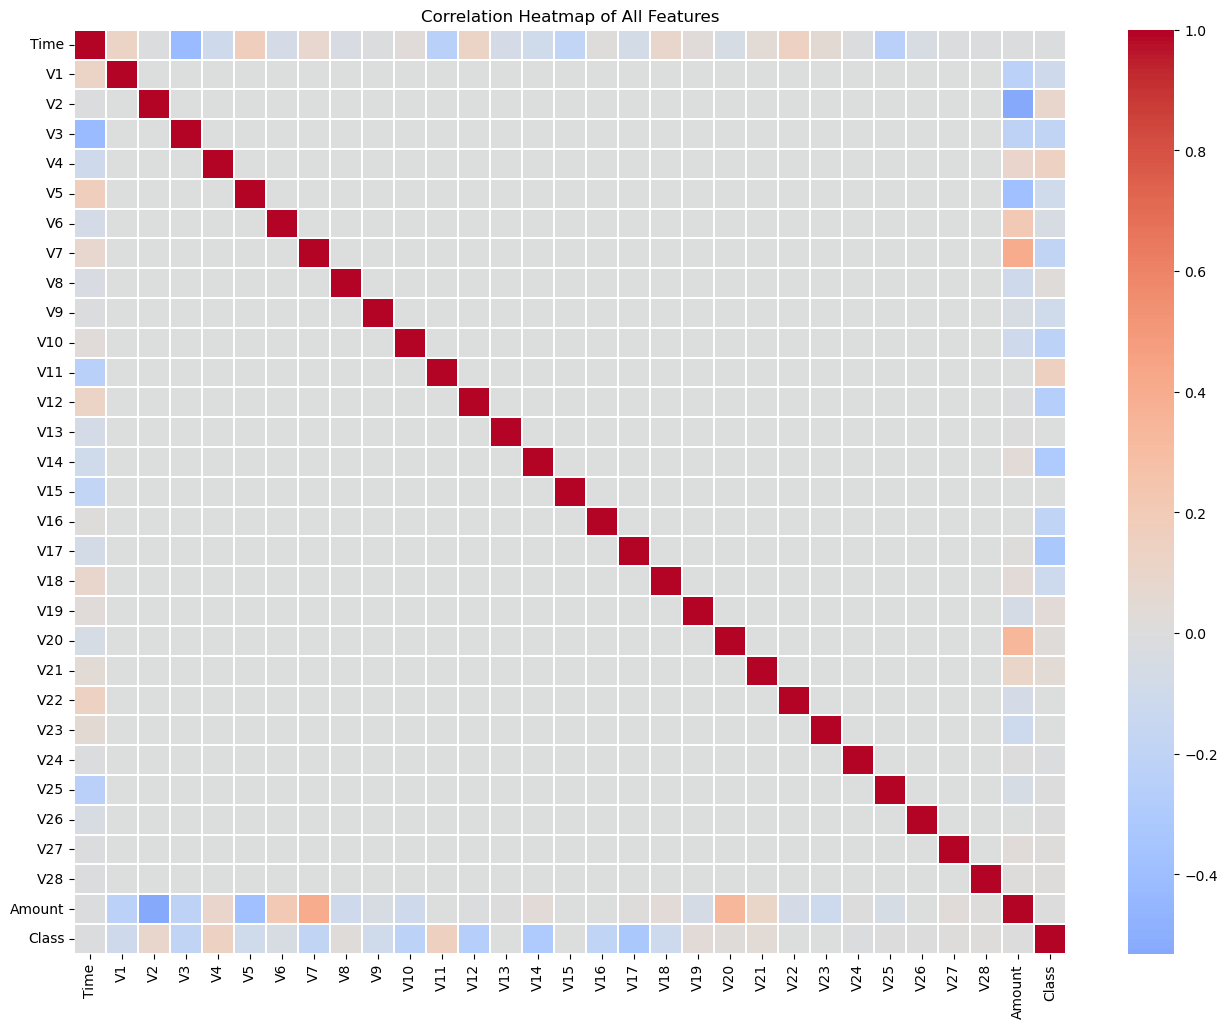

Top 10 features correlated with Class:
 V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
Name: Class, dtype: float64


In [6]:
# Correlation heatmap
plt.figure(figsize=(16, 12))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.1)
plt.title("Correlation Heatmap of All Features")
plt.show()

# Features most correlated with Class
corr_with_class = corr['Class'].drop('Class').sort_values(key=abs, ascending=False)
print("Top 10 features correlated with Class:\n", corr_with_class.head(10))


## Data Preprocessing

In [7]:
# Feature scaling for 'Amount' and 'Time'
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_time'] = scaler.fit_transform(df[['Time']])

# Drop original columns
df = df.drop(['Amount', 'Time'], axis=1)

# Rearranging columns so scaled features come first, Class stays last
scaled_amount = df.pop('scaled_amount')
scaled_time = df.pop('scaled_time')
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

df.head()


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,0.244964,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.342475,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,1.160686,-1.996562,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,0.140534,-1.996562,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,-0.073403,-1.996541,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


## Model Training

In [8]:
# Define features and target
X = df.drop('Class', axis=1)
y = df['Class']

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())


Feature matrix shape: (284807, 30)
Target distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


In [9]:
# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Fraud cases:", y_train.sum())
print("Test shape:", X_test.shape, " Fraud cases:", y_test.sum())


Train shape: (227845, 30)  Fraud cases: 394
Test shape: (56962, 30)  Fraud cases: 98


In [10]:
# Logistic Regression (with class_weight='balanced' to help with class imbalance)
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
log_reg.fit(X_train, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]


In [11]:
# Random Forest as a comparison model (often performs better on imbalanced fraud data)
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]


## Evaluation

=== Logistic Regression ===
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

Accuracy: 0.9754748779888347
ROC-AUC: 0.9721669425367221
Average Precision (PR-AUC): 0.7189463752156903


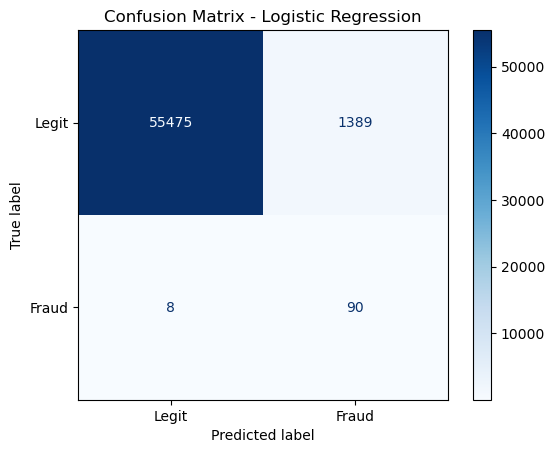

In [12]:
# Confusion matrix and classification report - Logistic Regression
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=['Legit', 'Fraud']))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
print("Average Precision (PR-AUC):", average_precision_score(y_test, y_proba_lr))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=['Legit', 'Fraud'], cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


=== Random Forest ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.84      0.81      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy: 0.999403110845827
ROC-AUC: 0.9811001795906883
Average Precision (PR-AUC): 0.8253777627168488


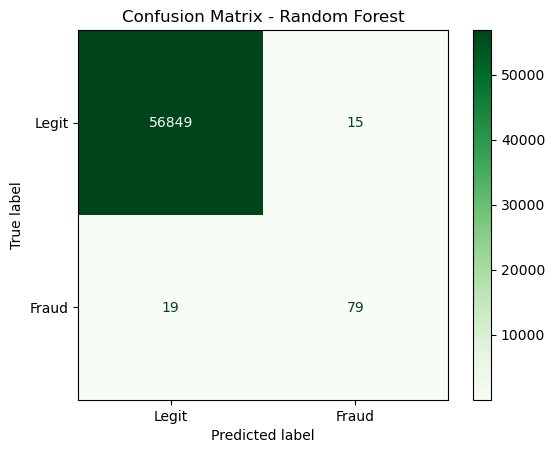

In [13]:
# Confusion matrix and classification report - Random Forest
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['Legit', 'Fraud']))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("Average Precision (PR-AUC):", average_precision_score(y_test, y_proba_rf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=['Legit', 'Fraud'], cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.show()


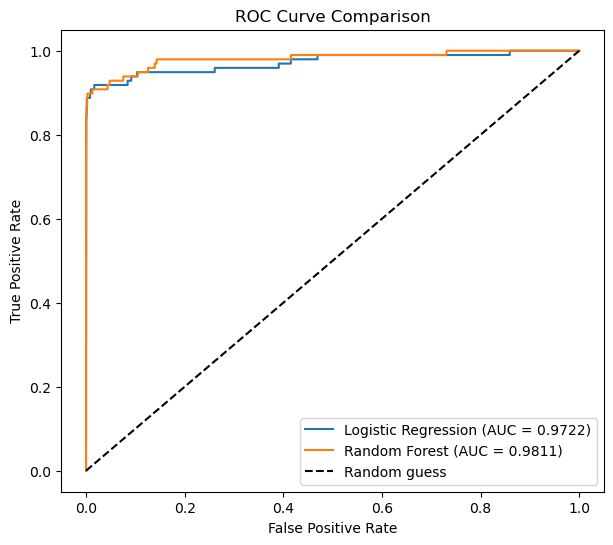

In [14]:
# ROC curves comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.4f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.4f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


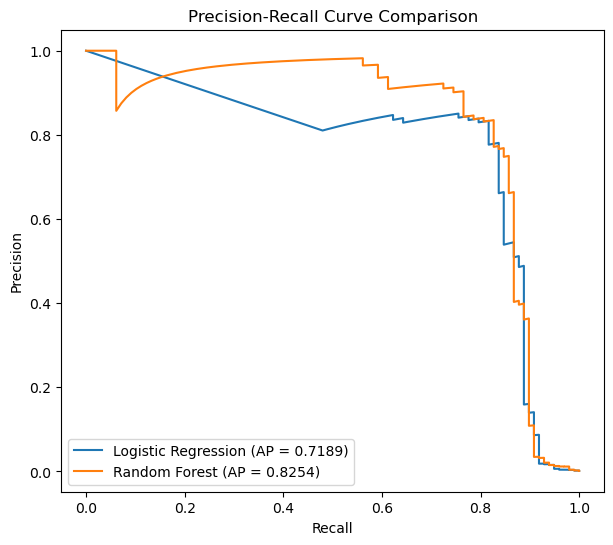

In [15]:
# Precision-Recall curves (more informative than ROC for highly imbalanced data)
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_proba_lr)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_proba_rf)

plt.figure(figsize=(7, 6))
plt.plot(rec_lr, prec_lr, label=f"Logistic Regression (AP = {average_precision_score(y_test, y_proba_lr):.4f})")
plt.plot(rec_rf, prec_rf, label=f"Random Forest (AP = {average_precision_score(y_test, y_proba_rf):.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()


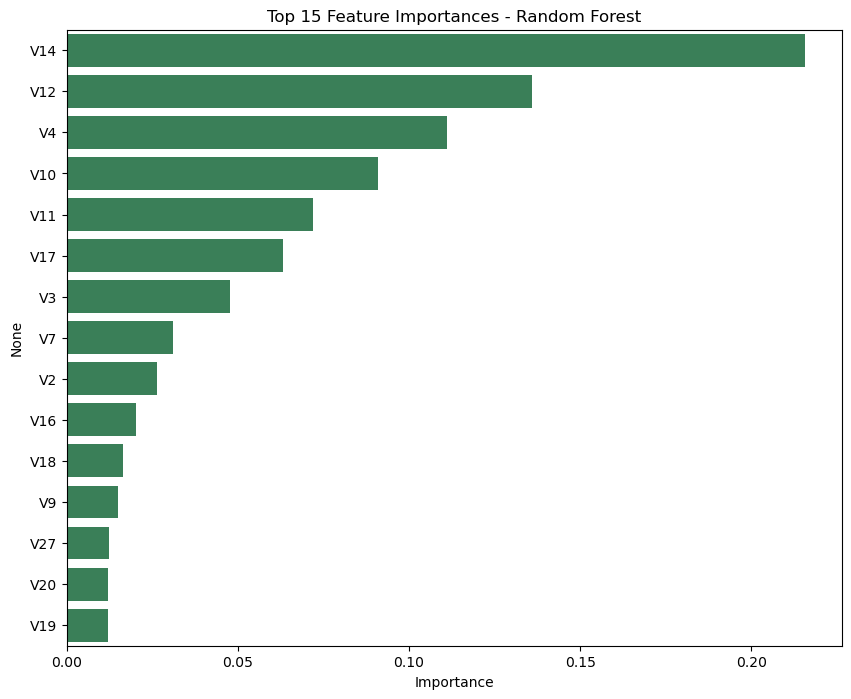

V14    0.215539
V12    0.135991
V4     0.111157
V10    0.090939
V11    0.071891
V17    0.063241
V3     0.047643
V7     0.031123
V2     0.026307
V16    0.020192
V18    0.016454
V9     0.015030
V27    0.012354
V20    0.012186
V19    0.011998
dtype: float64

In [16]:
# Feature importance from Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, color='seagreen')
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()

importances.head(15)


## Conclusion
- Built and compared two models — Logistic Regression and Random Forest — for binary fraud classification.
- Addressed feature scaling (`Amount`, `Time`) and class imbalance using `class_weight='balanced'`.
- Evaluated using confusion matrix, precision/recall/F1, ROC-AUC, and Precision-Recall AUC (more meaningful than plain accuracy given the ~0.17% fraud rate).
- Random Forest's feature importances highlight which anonymized `V` features contribute most to detecting fraud.
- Future work: try ensemble methods (e.g. XGBoost, LightGBM), SMOTE/undersampling for resampling, threshold tuning to balance precision vs recall, and cross-validation for more robust performance estimates.